In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("..")
from msna_pipeline import MSNA_pipeline
from msna_file_io import get_dataframes

In [2]:
 
dfs = get_dataframes(glob_regex="../MSNAS/MSNA*/MSNA*burstcomments*.txt")
pipeline = MSNA_pipeline(sampling_rate=250)
pipeline.load("../pretrained")

 64%|██████▎   | 28/44 [00:12<00:05,  2.78it/s]

list index out of range ../MSNAS/MSNA205/MSNA205_rest_burstcomments_downsampled_Emma.txt


 84%|████████▍ | 37/44 [00:15<00:02,  2.46it/s]

No bursts found.
'NoneType' object is not subscriptable ../MSNAS/MSNA172/MSNA172_rest_burstcomments_downsampled_Emma.txt


100%|██████████| 44/44 [00:18<00:00,  2.34it/s]
/Users/trippdow/Projects/HealthIntelligence/msna/examples/../msna_pipeline.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.

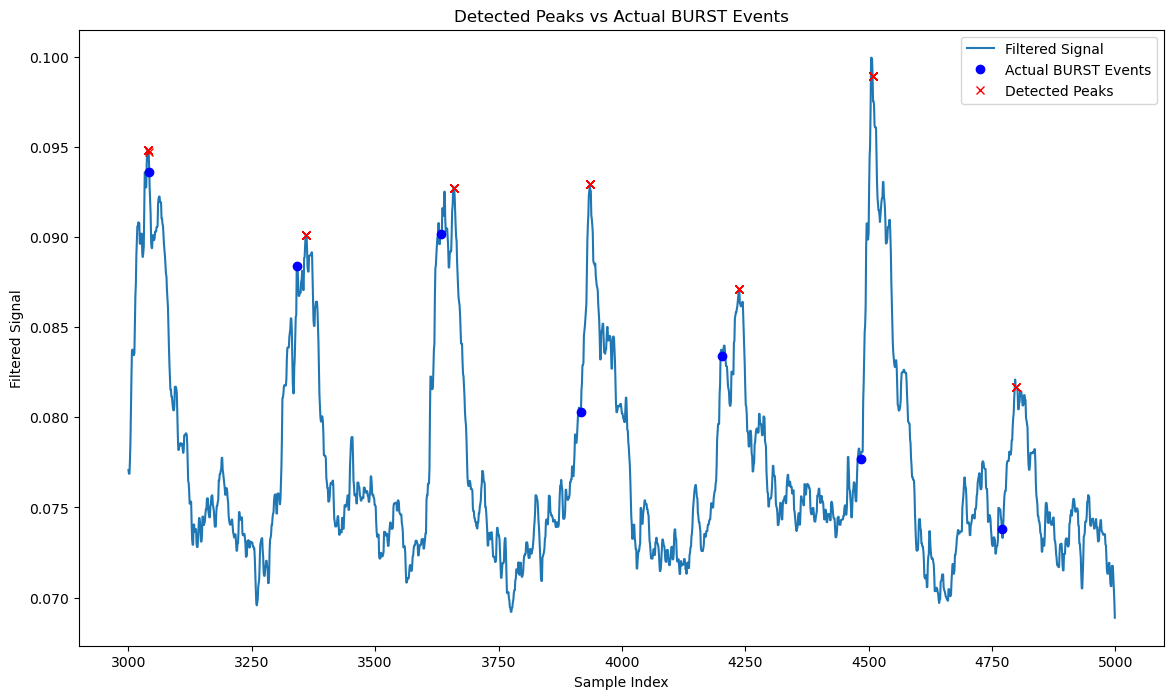

In [9]:
np.random.shuffle(dfs)
df = dfs[0]

# Extract indices of the actual BURST events
actual_burst_indices = df[df['BURST'] != 0].index

predicted_burst_indices = pipeline.predict(df)

plot_start = 3000 #np.random.randint(1000, 2000)
plot_end = 5000 #plot_start + np.random.randint(20000, 30000)

# Plot the results
plt.figure(figsize=(14, 8))
plt.plot(df['Integrated MSNA'][plot_start:plot_end], label='Filtered Signal')
plt.plot(actual_burst_indices[(actual_burst_indices<plot_end) & (actual_burst_indices>plot_start)], 
         df['Integrated MSNA'][actual_burst_indices[(actual_burst_indices<plot_end) & (actual_burst_indices>plot_start)]], 
         "o", label='Actual BURST Events', color='blue')
plt.plot(predicted_burst_indices[(predicted_burst_indices<plot_end) & (predicted_burst_indices>plot_start)], 
         df['Integrated MSNA'][predicted_burst_indices[(predicted_burst_indices<plot_end) & (predicted_burst_indices>plot_start)]], 
         "x", label='Detected Peaks', color='red')
plt.title('Detected Peaks vs Actual BURST Events')
plt.xlabel('Sample Index')
plt.ylabel('Filtered Signal')
plt.legend()
plt.show()